In [1]:
from langgraph.graph import StateGraph,START , END 
from langchain_groq import ChatGroq
from typing import TypedDict, Literal,Annotated
from pydantic import BaseModel,Field
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv


In [2]:
load_dotenv()


# 1. Generation — creative writing, needs high quality + some randomness for variety
generation_model = ChatGroq(
    model="openai/gpt-oss-120b",   # OpenAI's open-weight flagship, strong creative output, native tool-calling
    temperature=0.8,               # higher temp = more varied, punchy tweet drafts
)

# 2. Evaluation — needs judgment/reasoning, not creativity
evaluation_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.2,
)

# 3. Optimization — rewriting based on eval feedback, needs reliable instruction-following
optimization_model = ChatGroq(
    model="llama-3.3-70b-versatile",  # solid instruction-following, cheaper/faster than running gpt-oss-120b again
    temperature=0.5,                  # balanced — improves the tweet without drifting too far from intent
)

In [3]:
class TweetState(TypedDict):
    topic : str 
    tweet : str 
    evaluation : Literal["approved","need_improvement"]

    feedback : str 
    iteration : int 
    max_iteration : int 



In [4]:

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str = Field(description="One paragraph explaining strengths or weaknesses")

evaluation_structured_model = evaluation_model.with_structured_output(TweetEvaluation)

In [5]:
def generate_tweet(state:TweetState):
    topic = state["topic"]
    messages = [
        SystemMessage(content="""You are a viral tweet writer. You specialize in short, funny, highly relatable tweets that people screenshot and share. You write like a real person, not a brand or a comedian doing a bit. You follow the user's instructions strictly and output only the requested tweet — nothing else."""),
        
        HumanMessage(content=f"""Write a funny, viral-style tweet about: {topic}

        STRICT RULES:
        1. Length: max 280 characters. Prefer shorter (under 200) — punchy beats long.
        2. Voice: write like a real person venting or observing, not a brand or comedian doing a bit. No forced setup-punchline structure.
        3. Use AT LEAST ONE of these techniques, ideally blend two:
        - Irony: say the opposite of what's meant, or highlight a contradiction between expectation and reality.
        - Sarcasm: dry, deadpan exaggeration — sound sincere while clearly not being.
        - Observational humor: call out a specific, oddly-relatable behavior people do but never admit.
        - Cultural references: nod to a shared experience, trend, or in-joke — don't over-explain it, the humor is in recognition.
        4. Relatability: describe something the READER has felt or done. Use "you" or "me" or first person, not third-person generalizations.
        5. No hashtags. No emojis unless the emoji IS the punchline. No exclamation-point "hype" energy — virality comes from recognition, not enthusiasm.
        6. No explaining the joke. Trust the reader. Cut any sentence that exists only to clarify the joke.
        7. Avoid overused tweet formats (e.g. "nobody: / me:", "it's giving...", "the way I...") unless used ironically in a fresh way.
        8. Output ONLY the tweet text. No preamble, no quotation marks, no explanation.
        """)

            ]
    tweet = generation_model.invoke(messages).content

    return {"tweet":tweet}



In [6]:
def evaluate_tweet(state: TweetState):
    tweet = state["tweet"]
    messages = [
        SystemMessage(content="""You are a ruthless, highly experienced viral content critic. You have studied thousands of tweets that went viral versus thousands that flopped, and you know exactly what separates them. You do not give encouragement points. You do not soften your judgment to be nice. Your only job is to determine whether a tweet is actually good enough to post, or whether it needs more work. You always respond in the exact structured format requested — nothing else."""),

        HumanMessage(content=f"""Evaluate the following tweet strictly against the criteria below.

            `TWEET TO EVALUATE:
            \n\n{tweet}\n\n

            EVALUATION CRITERIA — check ALL of these:
            1. Humor mechanism: Does it clearly use irony, sarcasm, observational humor, or a cultural reference? Vague or generic "trying to be funny" without a real mechanism = fail.
            2. Relatability: Would a random stranger scrolling their feed think "this is literally me" within 1 second? If it requires niche context to land, or reads as an inside joke, it fails this.
            3. Punchiness: Is it short and tight? Any sentence that explains or over-clarifies the joke is an automatic weakness.
            4. Originality: Is it using an overused, played-out tweet format (e.g. "nobody: / me:", "it's giving...", "the way I...") in a stale, unironic way? If so, it fails this.
            5. Voice: Does it sound like a real person venting/observing, or does it sound like a brand, a comedian's written bit, or an AI being "quirky"? Anything that sounds artificial or try-hard fails this.
            6. Virality potential: Would someone actually screenshot this and send it to a friend? Be honest — most tweets do NOT clear this bar.

            BE STRICT. Do not approve a tweet just because it's decent. Only approve tweets that would genuinely stand out in a timeline. If it's mediocre, safe, generic, or leans on an overused format, mark it as needing improvement.

            OUTPUT FORMAT — respond with ONLY valid JSON, no markdown, no extra text, in exactly this structure:
            {{
            "evaluation": "approved" or "needs_improvement",
            "feedback": "One paragraph explaining the tweet's specific strengths and/or weaknesses, referencing the criteria above. Be concrete — point to exactly what works or what's failing, not generic praise/criticism."
            }}
            """)
                ]
    result = evaluation_structured_model.invoke(messages)

    return {"evaluation": result.evaluation,"feedback":result.feedback}



In [7]:
def optimize_tweet(state: TweetState):
    tweet = state["tweet"]
    feedback = state["feedback"]

    messages = [
        SystemMessage(content="""You are an expert tweet editor who specializes in fixing tweets that failed to land. You take a tweet and specific critique, then rewrite the tweet to directly address every weakness mentioned — without losing what already worked. You do not defend the original draft. You do not make cosmetic changes. You rewrite with intent. You follow instructions strictly and output only the revised tweet — nothing else."""),

        HumanMessage(content=f"""Improve the following tweet using the critic's feedback below.

            ORIGINAL TWEET:
            \n\n{tweet}\n\n

            CRITIC FEEDBACK (what's wrong with it):
            \n\n{feedback}\n\n

            STRICT RULES FOR THE REWRITE:
            1. Directly fix every weakness called out in the feedback. Do not ignore any point raised.
            2. Length: max 280 characters. Prefer shorter (under 200) — punchy beats long.
            3. Keep at least one clear humor mechanism: irony, sarcasm, observational humor, or cultural reference.
            4. Relatability: must read as something the READER has felt or done. Use "you" or "me", first person — not third-person generalizations.
            5. No hashtags. No emojis unless the emoji IS the punchline. No exclamation-point "hype" energy.
            6. No explaining the joke. Cut any line that exists only to clarify the humor.
            7. Do not fall back on overused tweet formats (e.g. "nobody: / me:", "it's giving...", "the way I...") unless used ironically in a genuinely fresh way.
            8. Do not simply reword the original — if the feedback says the core idea is weak, change the angle, not just the phrasing.
            9. Output ONLY the revised tweet text. No preamble, no quotation marks, no explanation, no "Here's the improved tweet:".
            """)
    ]

    improved_tweet = optimization_model.invoke(messages)

    return {
        "tweet": improved_tweet,
        "iteration": state["iteration"] + 1
    }

In [8]:
def route_evaluation(state:TweetState):
    if state["evaluation"] =="approved" or state["iteration"]>=state["max_iteration"]:
        return "approved"
    else:
        return "need_imporvement"

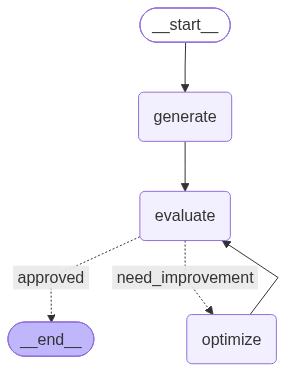

In [9]:
#define graph 
graph = StateGraph(TweetState)

#define nodes 
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("generate",generate_tweet)
graph.add_node("optimize",optimize_tweet)


#define edges 

graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")

graph.add_conditional_edges("evaluate",route_evaluation,{"approved":END,"need_improvement":"optimize"})
graph.add_edge('optimize','evaluate')

workflow = graph.compile()

workflow


In [12]:
initial_state = {
    'topic':"dhhdfh",
    "iteration":1,
    "max_iteration":5
}

final_state = workflow.invoke(initial_state)

In [13]:
print(final_state)

{'topic': 'dhhdfh', 'tweet': 'Every time I need a new password I just type dhhdfh because apparently my brain thinks a random keyboard slam is high security. Turns out my accounts are safer than my love life.', 'evaluation': 'approved', 'feedback': "This tweet excels in several areas: it uses observational humor and irony effectively, making it relatable to a wide audience who can identify with the struggle of creating new passwords. The punchiness is also well-executed, with a short and tight structure that doesn't over-clarify the joke. The originality criterion is met as it avoids overused tweet formats, instead offering a fresh perspective on a common experience. The voice sounds genuine, like a real person sharing a personal quirk, which enhances its relatability and humor. Lastly, the tweet has strong virality potential because its humor is universal and unexpected, making it likely that someone would screenshot and share it with a friend.", 'iteration': 1, 'max_iteration': 5}
